In [1]:
# Part 3 — CNN Classifier

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)


PyTorch version: 2.8.0


In [3]:
# Load and prepare the LFW dataset for the CNN

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

# Load the LFW dataset
lfw_people = fetch_lfw_people(
    min_faces_per_person=70,
    resize=0.4
)

# Get the original face images and labels
X_cnn = lfw_people.images
y_cnn = lfw_people.target

# Get dataset information
n_samples, h, w = X_cnn.shape
target_names = lfw_people.target_names
n_classes = len(target_names)

# Split into training and testing sets
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.25,
    random_state=42
)

# Add the channel dimension required by PyTorch
# (samples, height, width) -> (samples, channels, height, width)
X_train_cnn = X_train_cnn[:, np.newaxis, :, :]
X_test_cnn = X_test_cnn[:, np.newaxis, :, :]

print("Training images:", X_train_cnn.shape)
print("Testing images:", X_test_cnn.shape)
print("Image size:", h, "x", w)
print("Pixel range:", X_train_cnn.min(), "to", X_train_cnn.max())
print("Number of classes:", n_classes)

Training images: (966, 1, 50, 37)
Testing images: (322, 1, 50, 37)
Image size: 50 x 37
Pixel range: 0.0 to 1.0
Number of classes: 7


In [4]:
# Convert the LFW data to PyTorch tensors

X_train_tensor = torch.tensor(X_train_cnn, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_cnn, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_cnn, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_cnn, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training tensor shape:", X_train_tensor.shape)
print("Testing tensor shape:", X_test_tensor.shape)
print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training tensor shape: torch.Size([966, 1, 50, 37])
Testing tensor shape: torch.Size([322, 1, 50, 37])
Training batches: 31
Testing batches: 11


In [5]:
# Define the CNN architecture

class FaceCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            # Second convolutional layer
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            # Reduce spatial dimensions
            nn.MaxPool2d(kernel_size=2)
        )

        # After 2x2 pooling:
        # 50 x 37 -> 25 x 18
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(32 * 25 * 18, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create the model
model = FaceCNN(n_classes)

print(model)

FaceCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=14400, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [6]:
# Model summary and computation device

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

total_parameters = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("Computation device:", device)
print("Number of trainable parameters:", f"{total_parameters:,}")
print("\nCNN Architecture:")
print(model)

Computation device: mps
Number of trainable parameters: 1,853,799

CNN Architecture:
FaceCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=14400, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [7]:
# Configure the training process

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001


In [8]:
# Train the CNN

num_epochs = 20

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Record statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch  1/20 | Loss: 1.7757 | Accuracy: 0.3602
Epoch  2/20 | Loss: 1.7314 | Accuracy: 0.4006
Epoch  3/20 | Loss: 1.6541 | Accuracy: 0.4006
Epoch  4/20 | Loss: 1.4755 | Accuracy: 0.4627
Epoch  5/20 | Loss: 1.2411 | Accuracy: 0.5280
Epoch  6/20 | Loss: 0.9733 | Accuracy: 0.6398
Epoch  7/20 | Loss: 0.8388 | Accuracy: 0.6915
Epoch  8/20 | Loss: 0.7263 | Accuracy: 0.7484
Epoch  9/20 | Loss: 0.5899 | Accuracy: 0.7992
Epoch 10/20 | Loss: 0.4517 | Accuracy: 0.8530
Epoch 11/20 | Loss: 0.4250 | Accuracy: 0.8592
Epoch 12/20 | Loss: 0.3784 | Accuracy: 0.8758
Epoch 13/20 | Loss: 0.3272 | Accuracy: 0.8903
Epoch 14/20 | Loss: 0.2589 | Accuracy: 0.9151
Epoch 15/20 | Loss: 0.2140 | Accuracy: 0.9348
Epoch 16/20 | Loss: 0.1947 | Accuracy: 0.9410
Epoch 17/20 | Loss: 0.1949 | Accuracy: 0.9358
Epoch 18/20 | Loss: 0.1449 | Accuracy: 0.9545
Epoch 19/20 | Loss: 0.1111 | Accuracy: 0.9607
Epoch 20/20 | Loss: 0.1044 | Accuracy: 0.9689


In [9]:
# Evaluate the CNN on the unseen test set

model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total

print("CNN Test Results")
print("-" * 30)
print("Total testing images:", total)
print("Total correct:", correct)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

CNN Test Results
------------------------------
Total testing images: 322
Total correct: 280
Test accuracy: 0.8696
Test accuracy: 86.96%


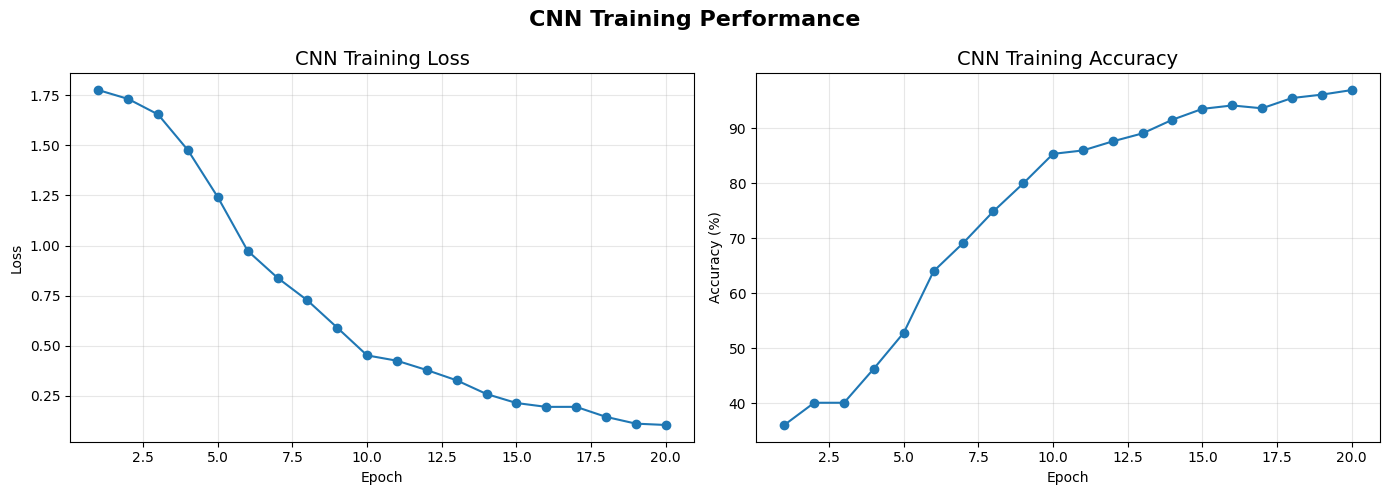

In [10]:
# Visualise CNN training performance

epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
axes[0].plot(epochs, train_losses, marker="o")
axes[0].set_title("CNN Training Loss", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

# Training accuracy
axes[1].plot(
    epochs,
    np.array(train_accuracies) * 100,
    marker="o"
)
axes[1].set_title("CNN Training Accuracy", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "CNN Training Performance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [11]:
# Detailed CNN classification performance

from sklearn.metrics import classification_report

print("CNN Classification Report")
print("=" * 70)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=target_names,
        zero_division=0
    )
)

CNN Classification Report
                   precision    recall  f1-score   support

     Ariel Sharon       0.82      0.69      0.75        13
     Colin Powell       0.81      0.95      0.88        60
  Donald Rumsfeld       0.80      0.74      0.77        27
    George W Bush       0.92      0.96      0.94       146
Gerhard Schroeder       0.83      0.60      0.70        25
      Hugo Chavez       0.92      0.80      0.86        15
       Tony Blair       0.82      0.75      0.78        36

         accuracy                           0.87       322
        macro avg       0.85      0.78      0.81       322
     weighted avg       0.87      0.87      0.87       322



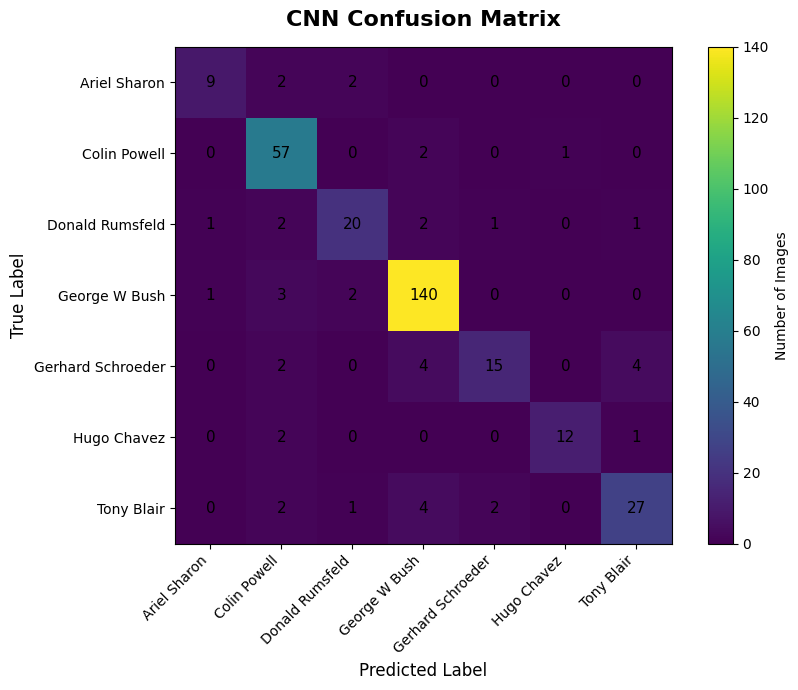

In [12]:
# CNN Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(cm)

ax.set_title(
    "CNN Confusion Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))

ax.set_xticklabels(target_names, rotation=45, ha="right")
ax.set_yticklabels(target_names)

# Add the number of predictions to each cell
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=11
        )

fig.colorbar(im, ax=ax, label="Number of Images")

plt.tight_layout()
plt.show()

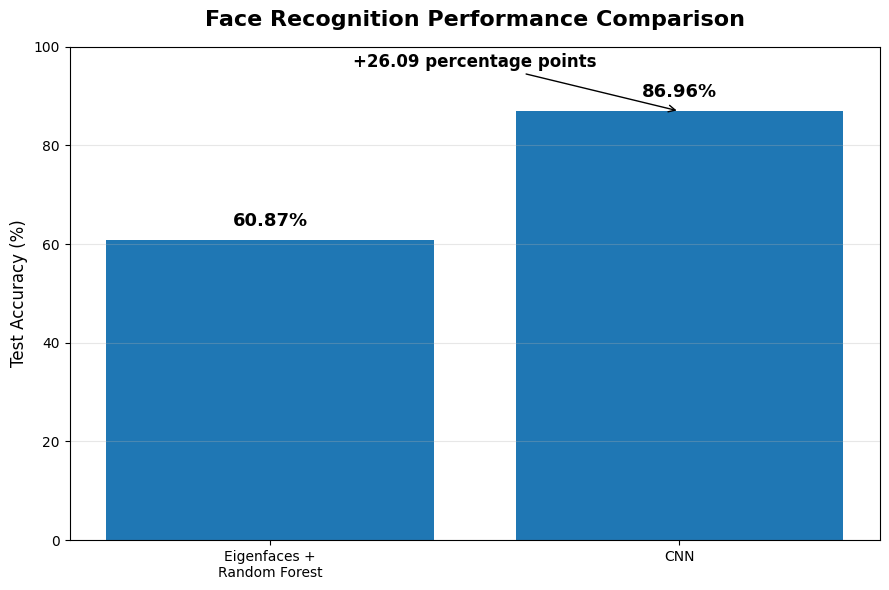

Eigenfaces + Random Forest: 60.87%
CNN:                       86.96%
Improvement:               +26.09 percentage points


In [15]:
# Compare the two face-recognition approaches

eigenfaces_accuracy = 0.6086956521739131
cnn_accuracy = test_accuracy

improvement = (cnn_accuracy - eigenfaces_accuracy) * 100

methods = [
    "Eigenfaces +\nRandom Forest",
    "CNN"
]

accuracies = [
    eigenfaces_accuracy * 100,
    cnn_accuracy * 100
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(methods, accuracies)

ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title(
    "Face Recognition Performance Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylim(0, 100)

# Accuracy labels above each bar
for bar, accuracy in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 2,
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

# Show the improvement between the two methods
ax.annotate(
    f"+{improvement:.2f} percentage points",
    xy=(1, cnn_accuracy * 100),
    xytext=(0.5, 96),
    ha="center",
    fontsize=12,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->")
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Eigenfaces + Random Forest: {eigenfaces_accuracy * 100:.2f}%")
print(f"CNN:                       {cnn_accuracy * 100:.2f}%")
print(f"Improvement:               +{improvement:.2f} percentage points")